In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/telco_processed.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,ServiceCount,ContractValue
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,29.850000,1,29.85
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,55.573529,3,1936.30
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,54.075000,3,107.70
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,40.905556,3,1903.50
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,75.825000,1,141.40


In [2]:
#dropping Unwanted Column and Defining Target Variale
df = df.drop(['AvgMonthlySpend','ContractValue','Churn'], axis=1)
y = df['MonthlyCharges']
X = df.drop('MonthlyCharges', axis=1)


In [3]:
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,TotalCharges,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,ServiceCount
0,0,0,1,0,1,0,1,29.85,True,False,...,False,False,False,False,False,False,False,True,False,1
1,1,0,0,0,34,1,0,1889.50,False,False,...,False,False,False,False,True,False,False,False,True,3
2,1,0,0,0,2,1,1,108.15,False,False,...,False,False,False,False,False,False,False,False,True,3
3,1,0,0,0,45,0,0,1840.75,True,False,...,False,False,False,False,True,False,False,False,False,3
4,0,0,0,0,2,1,1,151.65,False,False,...,False,False,False,False,False,False,False,True,False,1


In [4]:
from sklearn.model_selection import train_test_split
#Split dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

In [5]:
#Linear regression
from sklearn.linear_model import LinearRegression
import time

model = LinearRegression()

start = time.time()

model.fit(X_train, y_train)

training_time = time.time() - start

y_pred = model.predict(X_test)

In [6]:
#Calculating metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - (
    (1-r2)*(n-1)/(n-p-1)
)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)
print("Adjusted R² :", adj_r2)

MAE : 0.7858677938779708
MSE : 1.0710303227382247
RMSE: 1.0349059487403793
R²  : 0.9987925410318929
Adjusted R² : 0.998757235214112


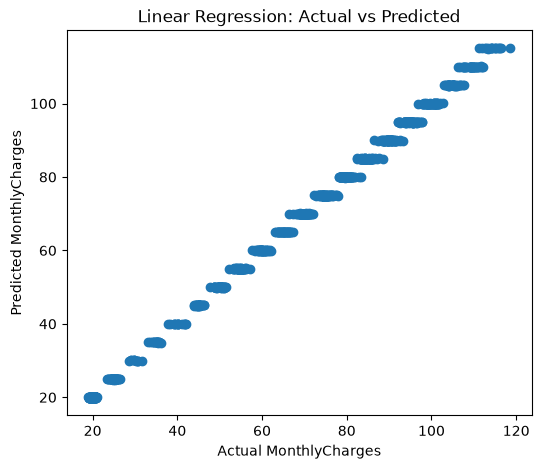

In [7]:
#Actual vs Predicted Scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual MonthlyCharges")
plt.ylabel("Predicted MonthlyCharges")

plt.title("Linear Regression: Actual vs Predicted")

plt.show()

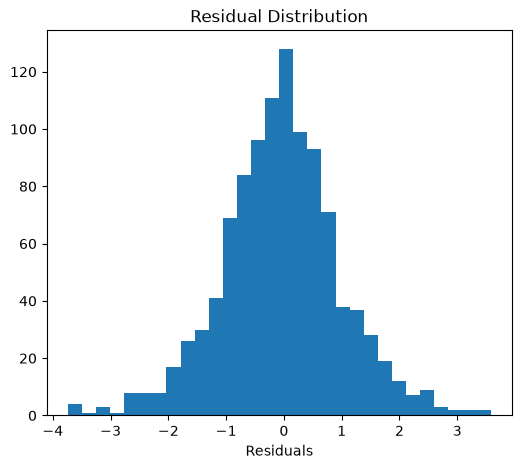

In [8]:
#Resiodual Distribution
residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.hist(
    residuals,
    bins=30
)

plt.title("Residual Distribution")

plt.xlabel("Residuals")

plt.show()

In [9]:
results_reg = []

results_reg.append([
    "Linear Regression",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])

In [10]:
corr = df.corr(numeric_only=True)

corr['MonthlyCharges'].sort_values(
    ascending=False
)

MonthlyCharges                           1.000000
InternetService_Fiber optic              0.787066
ServiceCount                             0.765874
TotalCharges                             0.650864
StreamingTV_Yes                          0.629603
StreamingMovies_Yes                      0.627429
MultipleLines_Yes                        0.490434
DeviceProtection_Yes                     0.482692
OnlineBackup_Yes                         0.441780
PaperlessBilling                         0.352150
TechSupport_Yes                          0.338304
OnlineSecurity_Yes                       0.296594
PaymentMethod_Electronic check           0.271625
tenure                                   0.247900
PhoneService                             0.247398
SeniorCitizen                            0.220173
Partner                                  0.096848
PaymentMethod_Credit card (automatic)    0.030550
Contract_One year                        0.004904
gender                                  -0.014569


In [11]:
#Ridge regreesion
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'alpha': 0.1}


In [12]:
best_ridge = grid.best_estimator_

start = time.time()

best_ridge.fit(X_train, y_train)

training_time = time.time() - start

y_pred = best_ridge.predict(X_test)

In [13]:
#Calculating metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)
print("Adjusted R² :", adj_r2)

MAE : 0.7858501081519229
MSE : 1.070991468789074
RMSE: 1.0348871768405838
R²  : 0.9987925848350871
Adjusted R² : 0.9987572802981014


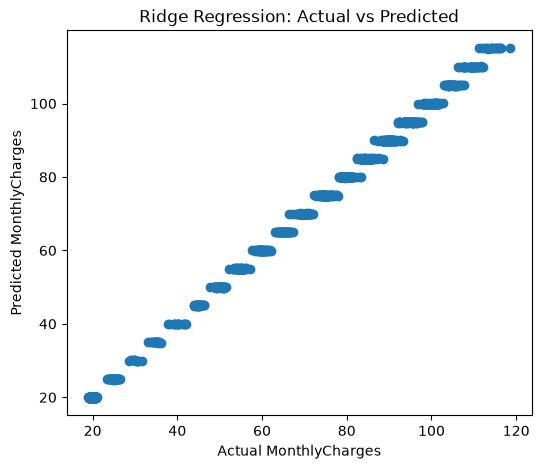

In [14]:
#Actual vs predicted Scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual MonthlyCharges")
plt.ylabel("Predicted MonthlyCharges")

plt.title("Ridge Regression: Actual vs Predicted")

plt.show()

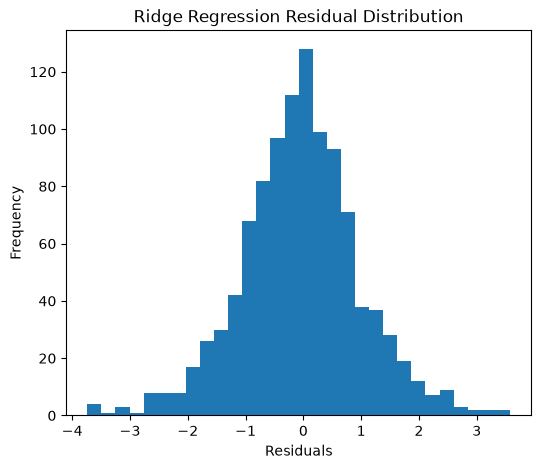

In [15]:
#Residual distrbution
residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.title("Ridge Regression Residual Distribution")

plt.show()

In [16]:
results_reg.append([
    "Ridge",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])

In [17]:
#Lasso Regression
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1]
}

grid = GridSearchCV(
    Lasso(max_iter=5000),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

best_lasso = grid.best_estimator_

start = time.time()
best_lasso.fit(X_train, y_train)
training_time = time.time() - start

y_pred = best_lasso.predict(X_test)

Best Parameters: {'alpha': 0.001}


In [18]:
#Calculating metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)
print("Adjusted R² :", adj_r2)

MAE : 0.7856468533528222
MSE : 1.07084290311072
RMSE: 1.0348153956676138
R²  : 0.998792752325173
Adjusted R² : 0.9987574526855582


In [19]:
results_reg.append([
    "Lasso",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])

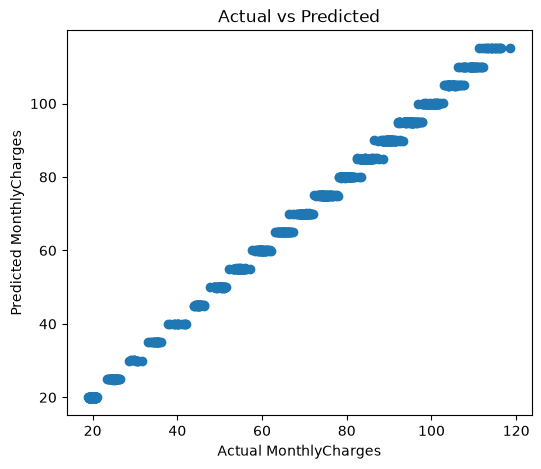

In [20]:
#Actual vs predicted scatter plot
plt.figure(figsize=(6,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual MonthlyCharges")
plt.ylabel("Predicted MonthlyCharges")

plt.title("Actual vs Predicted")

plt.show()

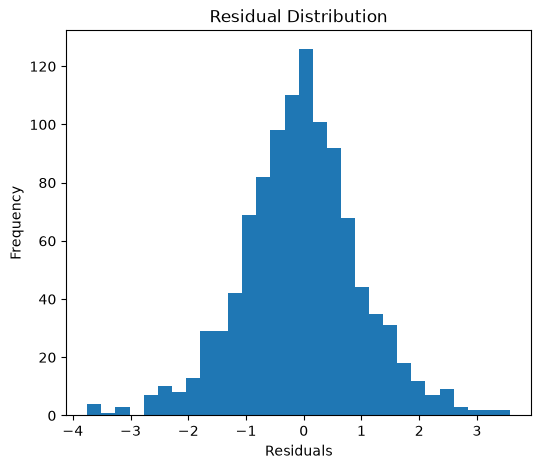

In [21]:
#Residual distribution
residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.show()

In [22]:
#Elastic net Regression
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1],
    'l1_ratio': [0.2, 0.5, 0.8]
}

grid = GridSearchCV(
    ElasticNet(max_iter=20000),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'alpha': 0.001, 'l1_ratio': 0.8}


In [23]:
best_elastic = grid.best_estimator_

start = time.time()

best_elastic.fit(X_train, y_train)

training_time = time.time() - start

y_pred = best_elastic.predict(X_test)

In [24]:
#Calculating metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)
print("Adjusted R² :", adj_r2)

MAE : 0.7856769268099473
MSE : 1.0709057103138393
RMSE: 1.034845742279418
R²  : 0.9987926815175412
Adjusted R² : 0.9987573798075278


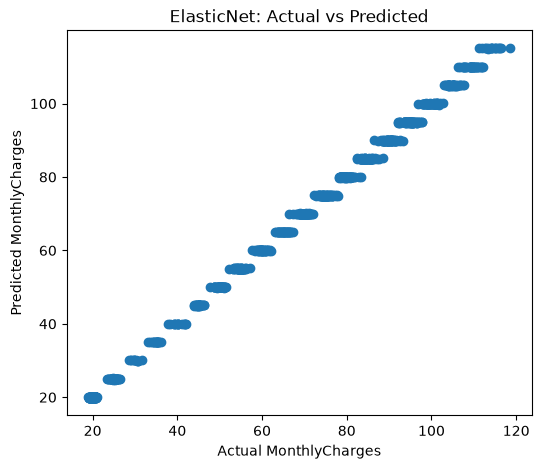

In [25]:
#actual vs predicted scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual MonthlyCharges")
plt.ylabel("Predicted MonthlyCharges")

plt.title("ElasticNet: Actual vs Predicted")

plt.show()

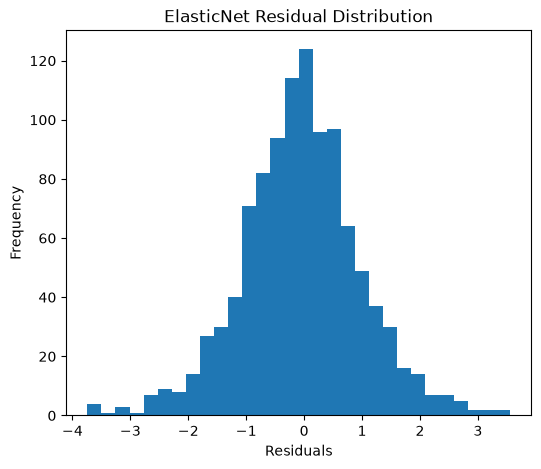

In [26]:
#Residual distribution
residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.hist(residuals, bins=30)

plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.title("ElasticNet Residual Distribution")

plt.show()

In [27]:
results_reg.append([
    "ElasticNet",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])

In [28]:
#Decision tree regressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'max_depth': [3, 5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}


In [29]:
best_dt = grid.best_estimator_

start = time.time()

best_dt.fit(X_train, y_train)

training_time = time.time() - start

y_pred = best_dt.predict(X_test)

In [30]:
#Calculating metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)
print("Adjusted R² :", adj_r2)

MAE : 0.8379722551221432
MSE : 1.2866759363437128
RMSE: 1.134317387834513
R²  : 0.9985494263183754
Adjusted R² : 0.9985070118832402


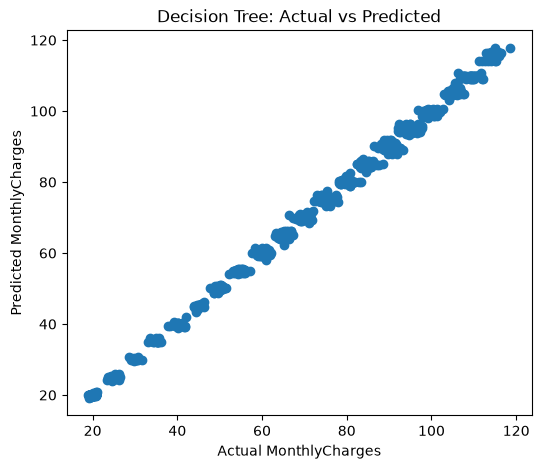

In [31]:
#actual and predicted scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual MonthlyCharges")
plt.ylabel("Predicted MonthlyCharges")

plt.title("Decision Tree: Actual vs Predicted")

plt.show()

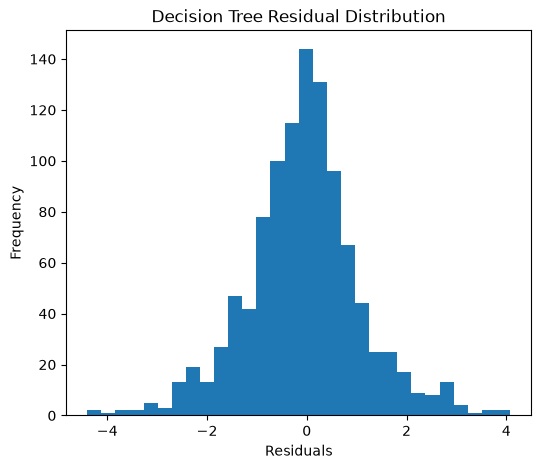

In [32]:
#Residual distribution
residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.hist(residuals, bins=30)

plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.title("Decision Tree Residual Distribution")

plt.show()

In [33]:
results_reg.append([
    "Decision Tree",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])

In [34]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import time

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [35]:
best_rf = grid.best_estimator_

start = time.time()

best_rf.fit(X_train, y_train)

training_time = time.time() - start

y_pred = best_rf.predict(X_test)

In [36]:
#Calculating metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)
print("Adjusted R² :", adj_r2)

MAE : 0.7843747569543177
MSE : 1.1495226722078689
RMSE: 1.0721579511470634
R²  : 0.9987040502681088
Adjusted R² : 0.9986661570010945


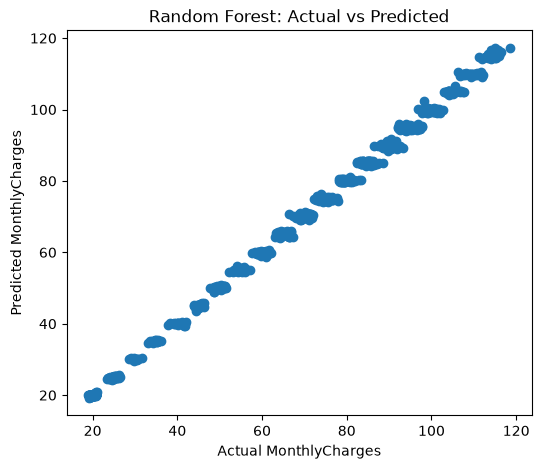

In [37]:
#Actual vs predicted scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual MonthlyCharges")
plt.ylabel("Predicted MonthlyCharges")

plt.title("Random Forest: Actual vs Predicted")

plt.show()

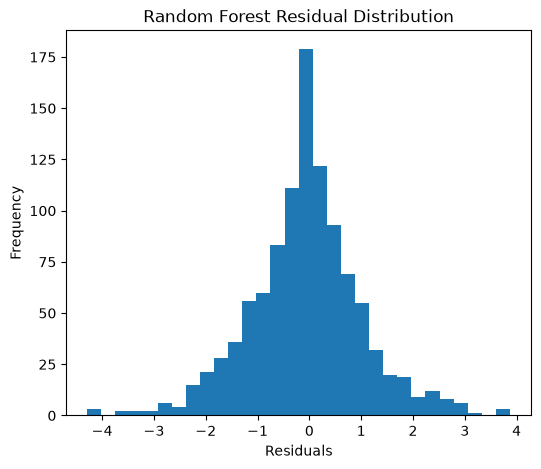

In [38]:
#Residual distribution
residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.hist(residuals, bins=30)

plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.title("Random Forest Residual Distribution")

plt.show()

In [39]:
results_reg.append([
    "Random Forest",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])

In [40]:
import pandas as pd

importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
)

top10 = importance.sort_values(
    ascending=False
).head(10)

print(top10)

InternetService_Fiber optic            0.612067
ServiceCount                           0.337430
PhoneService                           0.010353
MultipleLines_No phone service         0.007702
StreamingMovies_No internet service    0.005398
MultipleLines_Yes                      0.005356
TechSupport_No internet service        0.005095
StreamingTV_Yes                        0.003442
StreamingMovies_Yes                    0.003083
StreamingTV_No internet service        0.002694
dtype: float64


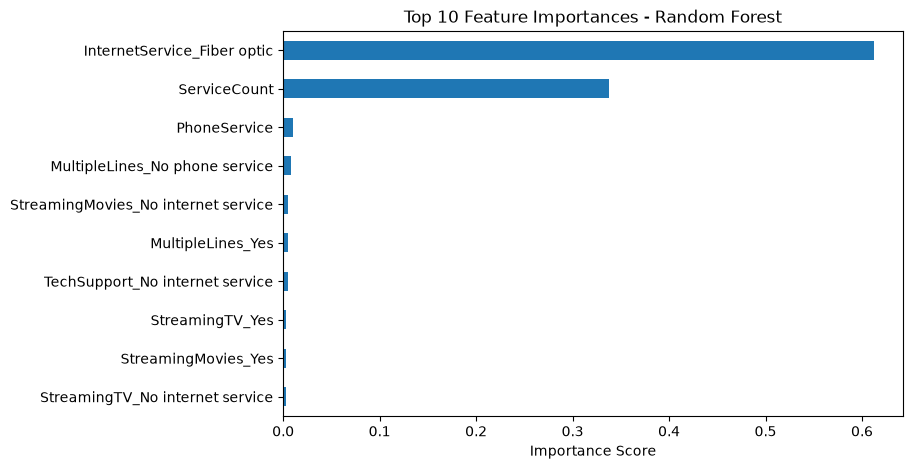

In [41]:
top10.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")

plt.show()

In [42]:
#random forest regressor complete


In [43]:

from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import time

In [44]:
#SVR Regressor
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [45]:
param_grid = {
    'C': [1, 10, 100],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(
    SVR(),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [46]:
best_svr = grid.best_estimator_

start = time.time()

best_svr.fit(X_train_scaled, y_train)

training_time = time.time() - start
y_pred = best_svr.predict(X_test_scaled)

In [47]:
#calculating metrics
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X_test.shape[1]

adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)
print("Adjusted R² :", adj_r2)

MAE : 0.8506325645030957
MSE : 1.2200019774548096
RMSE: 1.1045369968700955
R²  : 0.9986245932561273
Adjusted R² : 0.998584376684669


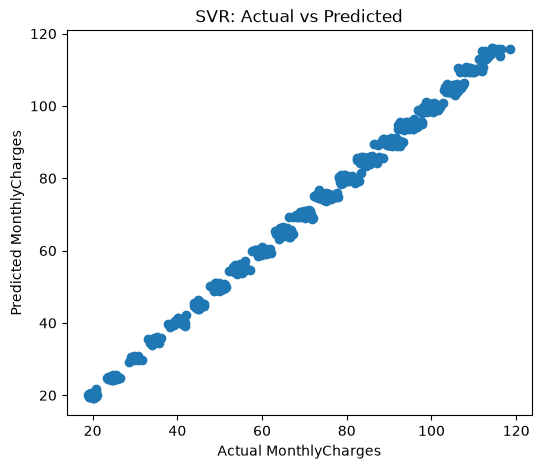

In [48]:
#Actual vs redicted scatter plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual MonthlyCharges")
plt.ylabel("Predicted MonthlyCharges")

plt.title("SVR: Actual vs Predicted")

plt.show()

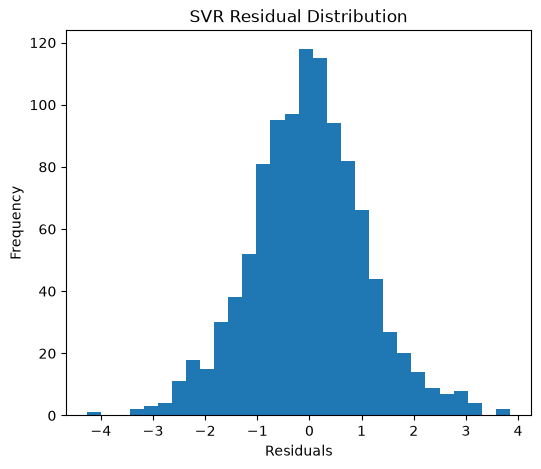

In [49]:
#Residual distribution
residuals = y_test - y_pred

plt.figure(figsize=(6,5))

plt.hist(residuals, bins=30)

plt.xlabel("Residuals")
plt.ylabel("Frequency")

plt.title("SVR Residual Distribution")

plt.show()

In [50]:
results_reg.append([
    "SVR",
    mae,
    mse,
    rmse,
    r2,
    adj_r2,
    training_time
])

In [51]:
results_reg_df = pd.DataFrame(
    results_reg,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R²",
        "Adj. R²",
        "Training Time"
    ]
)

results_reg_df

,Model,MAE,MSE,RMSE,R²,Adj. R²,Training Time
0,Linear Regression,0.785868,1.071030,1.034906,0.998793,0.998757,0.030465
1,Ridge,0.785850,1.070991,1.034887,0.998793,0.998757,0.025668
2,Lasso,0.785647,1.070843,1.034815,0.998793,0.998757,0.221174
3,ElasticNet,0.785677,1.070906,1.034846,0.998793,0.998757,0.292003
4,Decision Tree,0.837972,1.286676,1.134317,0.998549,0.998507,0.019552
5,Random Forest,0.784375,1.149523,1.072158,0.998704,0.998666,1.557418
6,SVR,0.850633,1.220002,1.104537,0.998625,0.998584,1.413667
